In [3]:
import gensim.downloader as api
from gensim.models import KeyedVectors
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [4]:
model_path = './GoogleNews-vectors-negative300.bin.gz'
model:KeyedVectors = KeyedVectors.load_word2vec_format(model_path, binary=True)

In [3]:
word1 = "Cat"
word2 = "Cow"

similarity_score = model.similarity(word1, word2)

print(f"Cosine similarity between '{word1}' and '{word2}': {similarity_score:.4f}")

Cosine similarity between 'Cat' and 'Cow': 0.4509


In [4]:
similar_words = model.most_similar("computer", topn=5)

print("\nMost similar to 'computer':")
for word, score in similar_words:
    print(f"{word}: {score:.4f}")


Most similar to 'computer':
computers: 0.7979
laptop: 0.6640
laptop_computer: 0.6549
Computer: 0.6473
com_puter: 0.6082


In [5]:
word_to_test = ['Boy', 'Cat', 'Horse', 'Cow', 'Bag']
res = np.zeros((len(word_to_test), len(word_to_test)))
for i, w1 in enumerate(word_to_test):
    for j, w2 in enumerate(word_to_test):
        similarity_score = model.similarity(w1, w2)
        print(f"Cosine similarity between '{w1}' and '{w2}': {similarity_score:.4f}")
        res[i][j] = similarity_score
        
print(res)

Cosine similarity between 'Boy' and 'Boy': 1.0000
Cosine similarity between 'Boy' and 'Cat': 0.3315
Cosine similarity between 'Boy' and 'Horse': 0.3207
Cosine similarity between 'Boy' and 'Cow': 0.3667
Cosine similarity between 'Boy' and 'Bag': 0.2860
Cosine similarity between 'Cat' and 'Boy': 0.3315
Cosine similarity between 'Cat' and 'Cat': 1.0000
Cosine similarity between 'Cat' and 'Horse': 0.4827
Cosine similarity between 'Cat' and 'Cow': 0.4509
Cosine similarity between 'Cat' and 'Bag': 0.3441
Cosine similarity between 'Horse' and 'Boy': 0.3207
Cosine similarity between 'Horse' and 'Cat': 0.4827
Cosine similarity between 'Horse' and 'Horse': 1.0000
Cosine similarity between 'Horse' and 'Cow': 0.5298
Cosine similarity between 'Horse' and 'Bag': 0.2642
Cosine similarity between 'Cow' and 'Boy': 0.3667
Cosine similarity between 'Cow' and 'Cat': 0.4509
Cosine similarity between 'Cow' and 'Horse': 0.5298
Cosine similarity between 'Cow' and 'Cow': 1.0000
Cosine similarity between 'Cow' 

In [6]:
result = model.most_similar(positive=['king', 'woman'], negative=['man'], topn=10)
print(result)

[('queen', 0.7118193507194519), ('monarch', 0.6189674139022827), ('princess', 0.5902431011199951), ('crown_prince', 0.5499460697174072), ('prince', 0.5377321839332581), ('kings', 0.5236844420433044), ('Queen_Consort', 0.5235945582389832), ('queens', 0.518113374710083), ('sultan', 0.5098593235015869), ('monarchy', 0.5087411403656006)]


In [7]:
word_to_test = ["banana", "gorilla", "mouse", "little", "yellow", "zookeeper"]
res = np.zeros((len(word_to_test), len(word_to_test)))
for i, w1 in enumerate(word_to_test):
    for j, w2 in enumerate(word_to_test):
        similarity_score = model.similarity(w1, w2)
        res[i][j] = similarity_score
        
print(res)

[[1.         0.28166884 0.11710549 0.17399918 0.27708334 0.09501518]
 [0.28166884 0.99999994 0.27250382 0.19586189 0.10338204 0.43446332]
 [0.11710549 0.27250382 1.         0.18726853 0.17619248 0.22148579]
 [0.17399918 0.19586189 0.18726853 1.         0.19679549 0.12861575]
 [0.27708334 0.10338204 0.17619248 0.19679549 0.99999994 0.06418598]
 [0.09501518 0.43446332 0.22148579 0.12861575 0.06418598 1.        ]]


In [8]:
word_to_test = ["lion", "gorilla", "mouse", "elephant",  "giraffe", "hyena", "armadillo", "banana", "yellow", "zookeeper", "walking", "hallway", "voice", "says", "smiling"]
res = np.zeros((len(word_to_test), len(word_to_test)), dtype=float)


for i, w1 in enumerate(word_to_test):
    for j, w2 in enumerate(word_to_test):
        similarity_score = model.similarity(w1, w2)
        res[i][j] = similarity_score * 100 // 1

res *= 0.01
print(res)
df = pd.DataFrame(res, columns=word_to_test, index=word_to_test)

[[ 1.    0.48  0.22  0.51  0.42  0.48  0.26  0.12  0.1   0.28  0.06  0.05
   0.11  0.05  0.08]
 [ 0.48  0.99  0.27  0.59  0.65  0.48  0.4   0.28  0.1   0.43  0.2   0.14
   0.08  0.11  0.13]
 [ 0.22  0.27  1.    0.26  0.21  0.26  0.25  0.11  0.17  0.22  0.1   0.12
   0.13  0.    0.1 ]
 [ 0.51  0.59  0.26  0.99  0.59  0.44  0.42  0.25  0.19  0.37  0.17  0.12
   0.14  0.08  0.12]
 [ 0.42  0.65  0.21  0.59  1.    0.48  0.44  0.22  0.14  0.47  0.18  0.18
   0.04  0.05  0.17]
 [ 0.48  0.48  0.26  0.44  0.48  1.    0.38  0.16  0.03  0.37  0.2   0.11
   0.11  0.    0.21]
 [ 0.26  0.4   0.25  0.42  0.44  0.38  1.    0.21  0.15  0.26  0.14  0.11
  -0.03 -0.02  0.11]
 [ 0.12  0.28  0.11  0.25  0.22  0.16  0.21  1.    0.27  0.09  0.07 -0.02
   0.02  0.05  0.12]
 [ 0.1   0.1   0.17  0.19  0.14  0.03  0.15  0.27  0.99  0.06  0.13  0.12
   0.07  0.03  0.19]
 [ 0.28  0.43  0.22  0.37  0.47  0.37  0.26  0.09  0.06  1.    0.11  0.15
   0.02  0.14  0.12]
 [ 0.06  0.2   0.1   0.17  0.18  0.2   0.14  0.07 

In [9]:
word_to_test = ["flashlight", "gorilla", "bicycle", "balloon", "zookeeper", "keys", "dog"]
res = np.zeros((len(word_to_test), len(word_to_test)), dtype=float)


for i, w1 in enumerate(word_to_test):
    for j, w2 in enumerate(word_to_test):
        similarity_score = model.similarity(w1, w2)
        res[i][j] = similarity_score * 100 // 1

res *= 0.01
df = pd.DataFrame(res, columns=word_to_test, index=word_to_test)
print(df)

            flashlight  gorilla  bicycle  balloon  zookeeper  keys   dog
flashlight        1.00     0.15     0.26     0.19       0.19  0.28  0.31
gorilla           0.15     0.99     0.24     0.17       0.43  0.09  0.39
bicycle           0.26     0.24     1.00     0.25       0.14  0.13  0.32
balloon           0.19     0.17     0.25     1.00       0.13  0.00  0.25
zookeeper         0.19     0.43     0.14     0.13       1.00  0.09  0.41
keys              0.28     0.09     0.13     0.00       0.09  0.99  0.15
dog               0.31     0.39     0.32     0.25       0.41  0.15  0.99


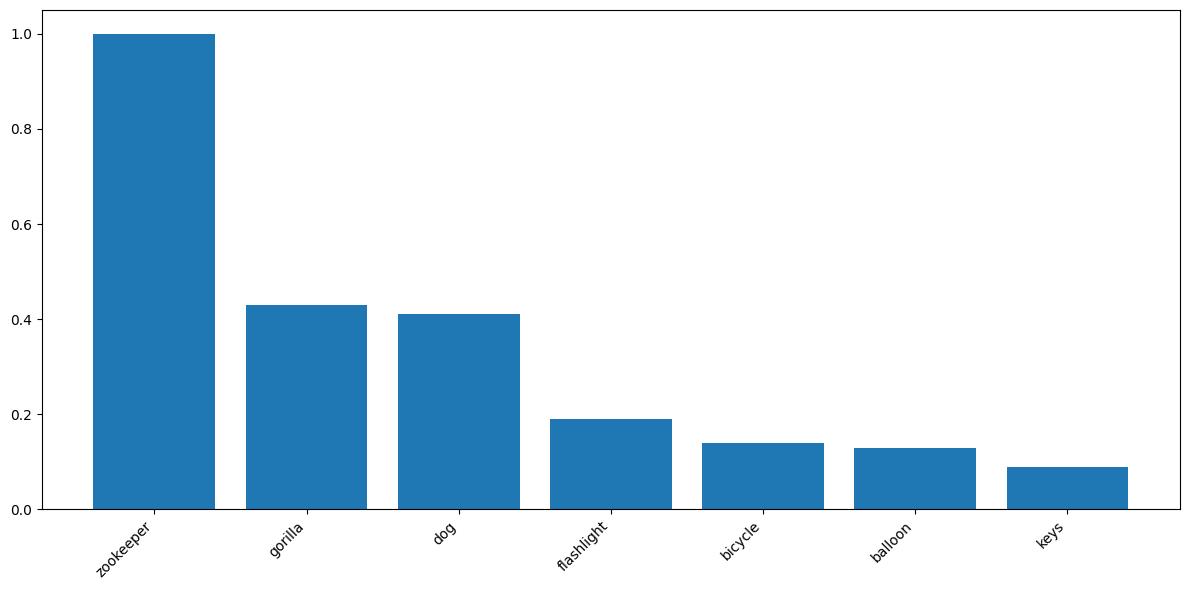

In [10]:
df = df.sort_values("zookeeper", ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(df.index, df["zookeeper"].values)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

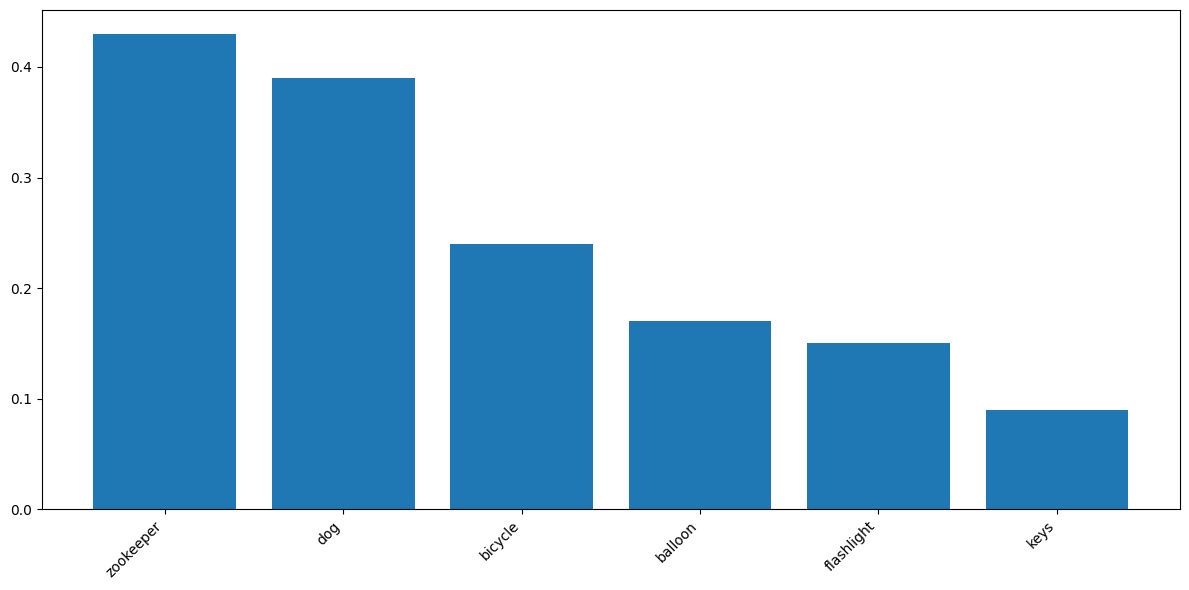

In [11]:
df = df.sort_values("gorilla", ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(df.index[1:], df["gorilla"].values[1:])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

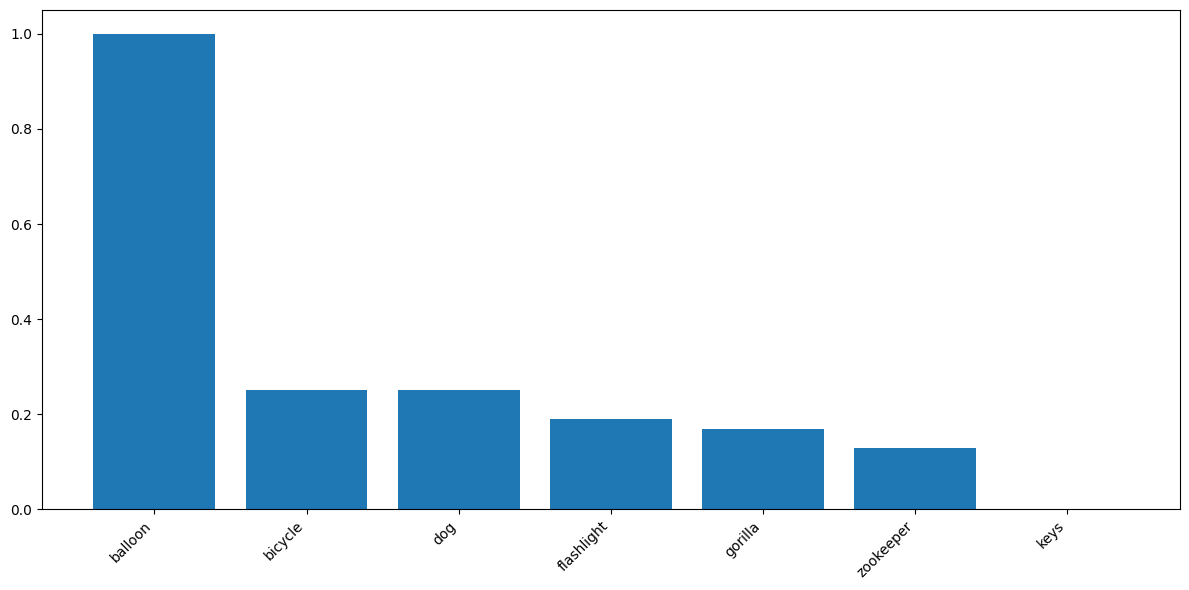

In [12]:
df = df.sort_values("balloon", ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(df.index, df["balloon"].values)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
word_to_test =  ["lion", "gorilla", "mouse", "elephant",  "giraffe", "banana", "yellow", "zookeeper", 'there', 'is', 'the', 'he',]
res = np.zeros((len(word_to_test), len(word_to_test)), dtype=float)


for i, w1 in enumerate(word_to_test):
    for j, w2 in enumerate(word_to_test):
        similarity_score = model.similarity(w1, w2)
        res[i][j] = similarity_score * 100 // 1

res *= 0.01
df = pd.DataFrame(res, columns=word_to_test, index=word_to_test)
print(df)

           lion  gorilla  mouse  elephant  giraffe  banana  yellow  zookeeper  \
lion       1.00     0.48   0.22      0.51     0.42    0.12    0.10       0.28   
gorilla    0.48     0.99   0.27      0.59     0.65    0.28    0.10       0.43   
mouse      0.22     0.27   1.00      0.26     0.21    0.11    0.17       0.22   
elephant   0.51     0.59   0.26      0.99     0.59    0.25    0.19       0.37   
giraffe    0.42     0.65   0.21      0.59     1.00    0.22    0.14       0.47   
banana     0.12     0.28   0.11      0.25     0.22    1.00    0.27       0.09   
yellow     0.10     0.10   0.17      0.19     0.14    0.27    0.99       0.06   
zookeeper  0.28     0.43   0.22      0.37     0.47    0.09    0.06       1.00   
there      0.04     0.01   0.05      0.10    -0.02    0.10    0.09      -0.05   
is         0.05     0.05   0.05      0.10     0.05    0.02    0.05      -0.04   
the        0.17     0.09   0.12      0.08     0.01    0.17    0.15      -0.08   
he         0.14     0.07  -0

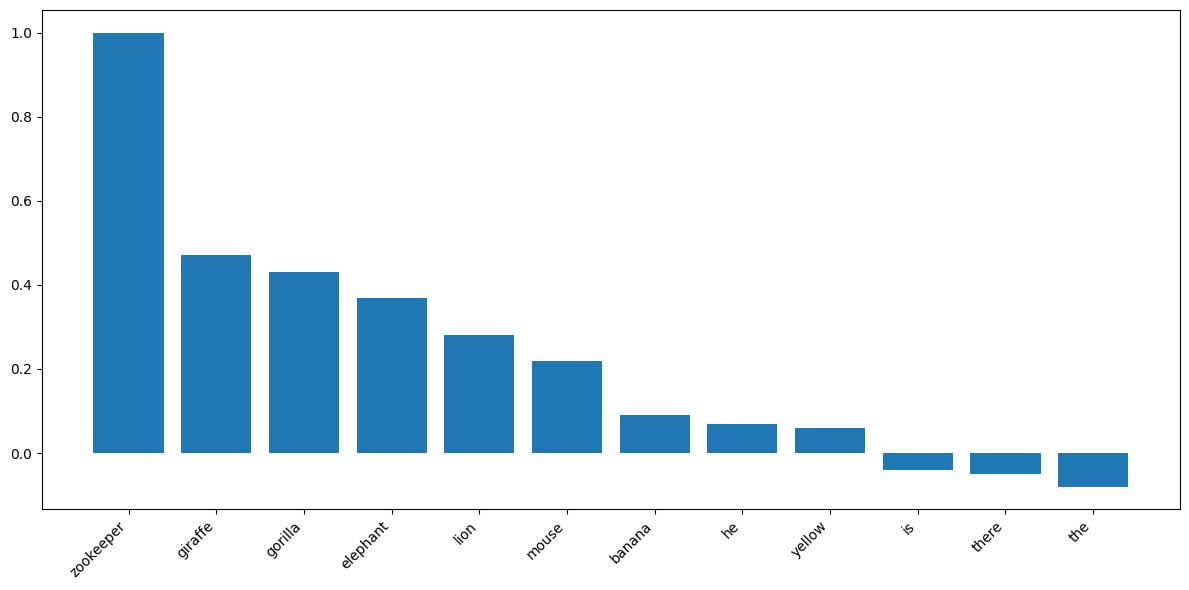

In [14]:
df = df.sort_values("zookeeper", ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(df.index, df["zookeeper"].values)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
test = dict(model.most_similar("zookeeper", topn=50))

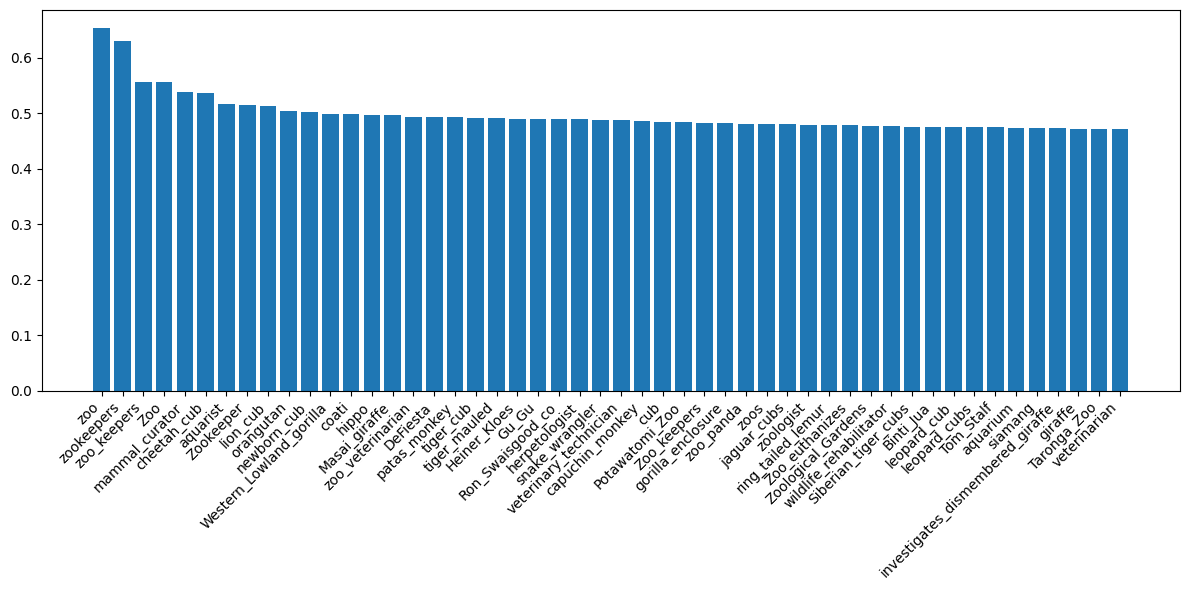

In [16]:
plt.figure(figsize=(12, 6))
plt.bar(test.keys(), test.values())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
result = model.most_similar(positive=['dark', 'zookeeper'], topn=10)
print(result)

[('grounds_Mannina', 0.5663505792617798), ('panic_Dovi', 0.5125754475593567), ('woodland_creature', 0.5091948509216309), ('nocturnal_creature', 0.5064539909362793), ('ant_eater', 0.5017927289009094), ('shepherd_husky_mix', 0.49292758107185364), ('furless', 0.49025821685791016), ('zoo', 0.4894355535507202), ('giraffes_rhinos', 0.4869827926158905), ('blackish_gray', 0.48593658208847046)]


In [18]:
result = model.most_similar(positive=['dark', 'zookeeper', 'see'], topn=10)
print(result)

[('panic_Dovi', 0.5171945691108704), ('Wretched_mortals_open', 0.515038013458252), ('grounds_Mannina', 0.511377215385437), ('snake_slither', 0.49252575635910034), ('wolfy', 0.4914783835411072), ('Blood_curdling', 0.4905625581741333), ('exclaim_Wow', 0.4902275502681732), ('stuffy_cabins', 0.4878194332122803), ('spokeswoman_Christan_Baumer', 0.48647022247314453), ('Siberian_tigers_wolves', 0.4861217737197876)]


In [19]:
word_to_test_tempo = ['zookeeper', 'flashlight', 'dark', 'click', 'good', 'night', 'gorilla', 'sleep', 'no', 'keys', 'sneaky', 'jingle', 'jangle', 'mouse', 'squeak', 'bicycle', 'tire', 'follow', 'balloon', 'cage', 'free', 'shine', 'tiptoe', 'uh', 'byebye', 'whoosh', 'banana', 'pull', 'elephant', 'thump', 'twist', 'lion', 'mane', 'rooooar', 'bone', 'snack', 'quiet', 'tall', 'giraffe', 'neck', 'streeeeetch', 'hyena', 'party', 'strong', 'armadillo', 'shell', 'tap', 'bottle', 'doll', 'parade', 'friends', 'legs', 'quietly', 'zoo', 'house', 'steps', 'step', 'stairs', 'lawn', 'me', 'asleep', 'lights', 'surprise', 'hallway', 'duck', 'scuttle', 'yummy', 'pictures', 'bedroom', 'full', 'sleepy', 'yawn', 'yaaaawn', 'cat', 'alarm', 'clock', 'lamp', 'nightstand', 'sleeping', 'pitch', 'black', 'listen', 'deep', 'growly', 'squeaky', 'seven', 'voices', 'eyes', 'blink', 'awake', 'light', 'shocked', 'mouth', 'smile', 'busted', 'sleepover', 'march', 'clomp', 'monkey', 'shhh', 'clink', 'snooze', 'snoring', 'zzzz', 'hey', 'peel', 'moon', 'stars']
all_word = ['neighborhood', 'make', 'hyena', 'orange', 'picture', 'rooooar', 'snuggled', 'drawer', 'by', 'night', 'watching', 'following', 'purple', 'wearing', 'him', 'pillow', 'was', 'smiling', 'comfy', 'edge', 'balloon', 'standing', 'ready', 'full', 'thought', 'friends', 'or', 'across', 'down', 'big', 'wall', 'looks', 'coming', 'banana', 'light', 'alone', 'finding', 'pitch', 'that', 'gives', 'turn', 'asleep', 'sleepy', 'head', 'wife', 'thing', 'page', 'different', 'hear', 'herself', 'know', 'dark', 'under', 'need', 'he', 'lot', 'moon', 'quietly', 'step', 'join', 'swing', 'hey', 'snack', 'who', 'neck', 'off', 'cuddled', 'at', 'there', 'peeking', 'a', 'back', 'mumbles', 'like', 'green', 'anymore', 'over', 'comes', 'drag', 'zzzz', 'foot', 'voices', 'finally', 'do', 'guessed', 'covers', 'animal', 'even', 'waiting', 'clink', 'white', 'wants', 'tired', 'as', 'but', 'listen', 'is', 'jingle', 'lock', 'pictures', 'behind', 'blue', 'snooze', 'leading', 'spot', 'yaaaawn', 'twist', 'alarm', 'does', 'pulling', 'going', 'sitting', 'answering', 'time', 'yellow', 'stretching', 'fuzzy', 'key', 'curtains', 'pull', 'them', 'bedroom', 'walks', 'cage', 'hurrying', 'click', 'not', 'shocked', 'from', 'shhh', 'itis', 'next', 'wait', 'how', 'tire', 'busted', 'scuttle', 'marching', 'lives', 'mane', 'she', 'the', 'fluffy', 'finger', 'past', 'again', 'closely', 'get', 'tap', 'for', 'other', 'must', 'blanket', 'bottle', 'friend', 'carpet', 'lion', 'stretch', 'ate', 'happy', 'donot', 'to', 'everything', 'all', 'wide', 'something', 'be', 'lights', 'dragging', 'flashlight', 'doesnot', 'whoosh', 'fly', 'squeak', 'goodness', 'reaches', 'they', 'sleeping', 'turned', 'now', 'monkey', 'yummy', 'letting', 'another', 'belong', 'those', 'staring', 'poor', 'room', 'said', 'stay', 'loves', 'we', 'keys', 'grass', 'on', 'putting', 'march', 'warm', 'climbs', 'out', 'elephant', 'shine', 'thatis', 'you', 'sleepover', 'way', 'follow', 'here', 'hanging', 'handle', 'voice', 'mouth', 'walked', 'talking', 'closer', 'tall', 'just', 'into', 'tiptoe', 'see', 'shell', 'in', 'my', 'lawn', 'look', 'our', 'hallway', 'inviting', 'byebye', 'surprise', 'put', 'good', 'having', 'toy', 'snoozing', 'this', 'pulls', 'holding', 'happened', 'me', 'away', 'curled', 'floor', 'taking', 'grey', 'knows', 'hand', 'dropped', 'popping', 'his', 'has', 'because', 'her', 'sneaky', 'husband', 'snoring', 'seven', 'unlock', 'ball', 'thump', 'silly', 'party', 'streeeeetch', 'belt', 'heard', 'tucked', 'your', 'being', 'zookeeper', 'string', 'barely', 'bone', 'never', 'lamp', 'belongs', 'have', 'sky', 'midnight', 'mister', 'bed', 'high', 'blink', 'very', 'outside', 'giraffe', 'already', 'getting', 'floating', 'cap', 'used', 'gorilla', 'themselves', 'made', 'eyes', 'mouse', 'uh', 'fits', 'go', 'making', 'sneaking', 'stealing', 'long', 'rug', 'gate', 'doll', 'houses', 'cat', 'baby', 'can', 'front', 'together', 'goodnight', 'bicycle', 'right', 'top', 'so', 'photos', 'sees', 'jangle', 'wheels', 'waving', 'with', 'are', 'zoo', 'oh', 'duck', 'others', 'busy', 'climbing', 'us', 'nightstand', 'toys', 'what', 'still', 'else', 'catch', 'really', 'doing', 'where', 'open', 'parade', 'one', 'reaching', 'hard', 'helper', 'squeaky', 'wow', 'fast', 'did', 'thinks', 'dear', 'perfect', 'quiet', 'whispering', 'found', 'awake', 'whole', 'smile', 'little', 'through', 'working', 'heavy', 'say', 'walking', 'i', 'using', 'legs', 'think', 'stairs', 'and', 'peel', 'free', 'stars', 'growly', 'steps', 'inside', 'come', 'tiny', 'door', 'black', 'strong', 'up', 'last', 'pink', 'it', 'shining', 'saying', 'deep', 'too', 'clock', 'animals', 'armadillo', 'leaning', 'want', 'goes', 'everyone', 'says', 'sleep', 'clomp', 'let', 'lying', 'house', 'their', 'no', 'yawn', 'two', 'sound', 'crawled', 'of']


In [20]:
print(len(word_to_test_tempo))
word_to_test = []
for w in word_to_test_tempo :
    if model.has_index_for(w):
        word_to_test.append(w)
print(len(word_to_test))
print(word_to_test)

print(len(all_word))
all_word_in_commun = []
for w in all_word :
    if model.has_index_for(w):
        all_word_in_commun.append(w)
    else:
        print(w)
print(len(all_word_in_commun))


108
104
['zookeeper', 'flashlight', 'dark', 'click', 'good', 'night', 'gorilla', 'sleep', 'no', 'keys', 'sneaky', 'jingle', 'jangle', 'mouse', 'squeak', 'bicycle', 'tire', 'follow', 'balloon', 'cage', 'free', 'shine', 'tiptoe', 'uh', 'whoosh', 'banana', 'pull', 'elephant', 'thump', 'twist', 'lion', 'mane', 'bone', 'snack', 'quiet', 'tall', 'giraffe', 'neck', 'hyena', 'party', 'strong', 'armadillo', 'shell', 'tap', 'bottle', 'doll', 'parade', 'friends', 'legs', 'quietly', 'zoo', 'house', 'steps', 'step', 'stairs', 'lawn', 'me', 'asleep', 'lights', 'surprise', 'hallway', 'duck', 'scuttle', 'yummy', 'pictures', 'bedroom', 'full', 'sleepy', 'yawn', 'cat', 'alarm', 'clock', 'lamp', 'nightstand', 'sleeping', 'pitch', 'black', 'listen', 'deep', 'growly', 'squeaky', 'seven', 'voices', 'eyes', 'blink', 'awake', 'light', 'shocked', 'mouth', 'smile', 'busted', 'sleepover', 'march', 'clomp', 'monkey', 'shhh', 'clink', 'snooze', 'snoring', 'zzzz', 'hey', 'peel', 'moon', 'stars']
410
rooooar
a
yaaaa

In [21]:
print(all_word_in_commun)

['neighborhood', 'make', 'hyena', 'orange', 'picture', 'snuggled', 'drawer', 'by', 'night', 'watching', 'following', 'purple', 'wearing', 'him', 'pillow', 'was', 'smiling', 'comfy', 'edge', 'balloon', 'standing', 'ready', 'full', 'thought', 'friends', 'or', 'across', 'down', 'big', 'wall', 'looks', 'coming', 'banana', 'light', 'alone', 'finding', 'pitch', 'that', 'gives', 'turn', 'asleep', 'sleepy', 'head', 'wife', 'thing', 'page', 'different', 'hear', 'herself', 'know', 'dark', 'under', 'need', 'he', 'lot', 'moon', 'quietly', 'step', 'join', 'swing', 'hey', 'snack', 'who', 'neck', 'off', 'cuddled', 'at', 'there', 'peeking', 'back', 'mumbles', 'like', 'green', 'anymore', 'over', 'comes', 'drag', 'zzzz', 'foot', 'voices', 'finally', 'do', 'guessed', 'covers', 'animal', 'even', 'waiting', 'clink', 'white', 'wants', 'tired', 'as', 'but', 'listen', 'is', 'jingle', 'lock', 'pictures', 'behind', 'blue', 'snooze', 'leading', 'spot', 'twist', 'alarm', 'does', 'pulling', 'going', 'sitting', 'an

In [22]:
res = np.zeros((len(word_to_test), len(word_to_test)), dtype=float)


for i, w1 in enumerate(word_to_test):
    for j, w2 in enumerate(word_to_test):
        similarity_score = model.similarity(w1, w2)
        res[i][j] = similarity_score
        
df = pd.DataFrame(res, columns=word_to_test, index=word_to_test)
df.to_csv(path_or_buf="corelation_Google_important_word.csv", float_format="%.5f", index=True)

In [23]:
print(len(word_to_test_tempo))
word_to_test = []
for w in word_to_test_tempo :
    if model.has_index_for(w):
        word_to_test.append(w)
print(len(word_to_test))
print(word_to_test)

108
104
['zookeeper', 'flashlight', 'dark', 'click', 'good', 'night', 'gorilla', 'sleep', 'no', 'keys', 'sneaky', 'jingle', 'jangle', 'mouse', 'squeak', 'bicycle', 'tire', 'follow', 'balloon', 'cage', 'free', 'shine', 'tiptoe', 'uh', 'whoosh', 'banana', 'pull', 'elephant', 'thump', 'twist', 'lion', 'mane', 'bone', 'snack', 'quiet', 'tall', 'giraffe', 'neck', 'hyena', 'party', 'strong', 'armadillo', 'shell', 'tap', 'bottle', 'doll', 'parade', 'friends', 'legs', 'quietly', 'zoo', 'house', 'steps', 'step', 'stairs', 'lawn', 'me', 'asleep', 'lights', 'surprise', 'hallway', 'duck', 'scuttle', 'yummy', 'pictures', 'bedroom', 'full', 'sleepy', 'yawn', 'cat', 'alarm', 'clock', 'lamp', 'nightstand', 'sleeping', 'pitch', 'black', 'listen', 'deep', 'growly', 'squeaky', 'seven', 'voices', 'eyes', 'blink', 'awake', 'light', 'shocked', 'mouth', 'smile', 'busted', 'sleepover', 'march', 'clomp', 'monkey', 'shhh', 'clink', 'snooze', 'snoring', 'zzzz', 'hey', 'peel', 'moon', 'stars']


In [24]:
word1, word2 = "zookeeper", "flashlight"
similarity_score = model.similarity(word1, word2)

print(f"Cosine similarity between '{word1}' and '{word2}': {similarity_score:.4f}")

Cosine similarity between 'zookeeper' and 'flashlight': 0.1964


# Only some word (important word 104)

In [25]:
valid_vectors = []

for word in word_to_test:
    valid_vectors.append(model[word])

# Shape will be (N_words, 300)
google_matrix = np.array(valid_vectors)
print(google_matrix.shape)

np.savez(
    'google_sub_embed.npz', 
    vectors=google_matrix, 
    words=word_to_test
)

(104, 300)


# All word in commun (401)

In [27]:
valid_vectors = []

for word in all_word_in_commun:
    print(word)
    valid_vectors.append(model[word])

# Shape will be (N_words, 300)
google_matrix = np.array(valid_vectors)
print(google_matrix.shape)

np.savez(
    'google_sub_embed_all_word.npz', 
    vectors=google_matrix, 
    words=all_word_in_commun
)

neighborhood
make
hyena
orange
picture
snuggled
drawer
by
night
watching
following
purple
wearing
him
pillow
was
smiling
comfy
edge
balloon
standing
ready
full
thought
friends
or
across
down
big
wall
looks
coming
banana
light
alone
finding
pitch
that
gives
turn
asleep
sleepy
head
wife
thing
page
different
hear
herself
know
dark
under
need
he
lot
moon
quietly
step
join
swing
hey
snack
who
neck
off
cuddled
at
there
peeking
back
mumbles
like
green
anymore
over
comes
drag
zzzz
foot
voices
finally
do
guessed
covers
animal
even
waiting
clink
white
wants
tired
as
but
listen
is
jingle
lock
pictures
behind
blue
snooze
leading
spot
twist
alarm
does
pulling
going
sitting
answering
time
yellow
stretching
fuzzy
key
curtains
pull
them
bedroom
walks
cage
hurrying
click
not
shocked
from
shhh
itis
next
wait
how
tire
busted
scuttle
marching
lives
mane
she
the
fluffy
finger
past
again
closely
get
tap
for
other
must
blanket
bottle
friend
carpet
lion
stretch
ate
happy
donot
everything
all
wide
something
be

In [13]:
cluster = ["giraffe", "elephant", "mouse", "lion", "hyena", "armadillo", "gorilla"]
sim_clus = []
for word_a in cluster:
    print(word_a)
    print(model.most_similar(word_a, topn=10))
    print()
    for word_b in cluster:
        if word_a == word_b : continue
        similarity_score = model.similarity(word_a, word_b)
        sim_clus.append(similarity_score)
print(sim_clus)
print(np.mean(sim_clus))
print(np.std(sim_clus))

giraffe
[('giraffes', 0.68833327293396), ('gorilla', 0.6594595313072205), ('hippopotamus', 0.6431108117103577), ('zebra', 0.6372909545898438), ('rhinoceros', 0.6188209652900696), ('rhino', 0.6172139048576355), ('hippo', 0.6081927418708801), ('reticulated_giraffe', 0.6048251390457153), ('elephant', 0.5931813716888428), ('penguin_chick', 0.5868645906448364)]

elephant
[('elephants', 0.7806671261787415), ('rhino', 0.6780353784561157), ('pachyderm', 0.6761021018028259), ('tiger', 0.6681442856788635), ('rhinoceros', 0.6430982351303101), ('tigers', 0.6049250364303589), ('hippo', 0.6039146780967712), ('gorilla', 0.5969827175140381), ('giraffe', 0.593181312084198), ('rhinos', 0.5868902206420898)]

mouse
[('Logitech_MX_Revolution', 0.6175230741500854), ('Razer_Mamba', 0.5994570851325989), ('mice', 0.5896884799003601), ('cordless_laser', 0.5652030110359192), ('VX_Nano', 0.5619357824325562), ('Logitech_MX###', 0.5604779124259949), ('keyboard_arrow_keys', 0.5545550584793091), ('Logitech_G9x', 0.55

[2]
